In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bestsellers with categories.csv")

In [2]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [3]:
df.shape

(550, 7)

Про скільки книг зберігає дані датасет? Відповідь: 550

In [4]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

In [5]:
df.isna().sum()

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64

Чи є в якихось змінних пропуски? (Так / ні) Відповідь: ні

In [6]:
df["genre"].unique()

<StringArray>
['Non Fiction', 'Fiction']
Length: 2, dtype: str

Які є унікальні жанри? Відповідь: 'Non Fiction', 'Fiction'

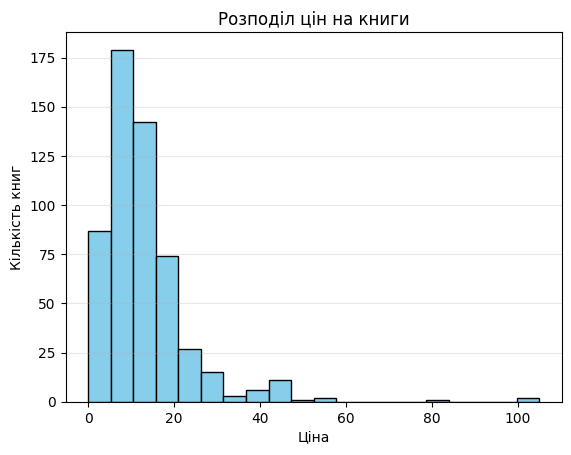

In [7]:
df['price'].plot(kind='hist', bins=20, edgecolor='black', color='skyblue')
plt.title('Розподіл цін на книги')
plt.xlabel('Ціна')
plt.ylabel('Кількість книг')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [8]:
df["price"].max(), df["price"].min(), df["price"].mean(), df["price"].median()

(np.int64(105), np.int64(0), np.float64(13.1), np.float64(11.0))

Максимальна ціна? Відповідь: 105
Мінімальна ціна? Відповідь: 0
Середня ціна? Відповідь: 13.1
Медіанна ціна? Відповідь: 11

In [9]:
df["user_rating"].max()

np.float64(4.9)

Який рейтинг у датасеті найвищий? Відповідь: 4.9

In [10]:
df_max_rating = df[df["user_rating"] == df["user_rating"].max()]
len(df_max_rating)

52

Скільки книг мають такий рейтинг? Відповідь: 52

In [11]:
df_max_reviews = df[df["reviews"] == df["reviews"].max()]
df_max_reviews['name']

534    Where the Crawdads Sing
Name: name, dtype: str

Яка книга має найбільше відгуків? Відповідь: Where the Crawdads Sing

In [12]:
max_2015 = df[df["year"] == 2015].max()
max_2015

name                 Wonder
author         Thug Kitchen
user_rating             4.9
reviews               79446
price                    46
year                   2015
genre           Non Fiction
dtype: object

З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)? Відповідь: Wonder

In [13]:
books_2010 = len(df[(df["year"] == 2010) & (df["genre"] == "Fiction")])
books_2010

20

Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)? Відповідь: 20

In [14]:
df_1 = len(df[(df["user_rating"] == 4.9) & (df["year"].isin([2010, 2011]))])
df_1

1

Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)? Відповідь: 1

In [15]:
df_2 = df[(df["year"] == 2015) & (df["price"] < 8)].sort_values(by="price")
df_2

,name,author,user_rating,reviews,price,year,genre
507,To Kill a Mockingbird,Harper Lee,4.8,26234,0,2015,Fiction
210,Laugh-Out-Loud Jokes for Kids,Rob Elliott,4.6,6990,4,2015,Non Fiction
206,Knock-Knock Jokes for Kids,Rob Elliott,4.5,3673,4,2015,Non Fiction
111,First 100 Words,Roger Priddy,4.7,17323,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
89,Dover Creative Haven Art Nouveau Animal Design...,Marty Noble,4.6,2134,5,2015,Non Fiction
478,The Very Hungry Caterpillar,Eric Carle,4.9,19546,5,2015,Fiction
201,Killing Reagan: The Violent Assault That Chang...,Bill O'Reilly,4.6,5235,5,2015,Non Fiction


Яка книга остання у відсортованому списку? Відповідь: Old School (Diary of a Wimpy Kid #10)

In [16]:
grouped_by_genre = df.groupby(["genre"]).agg(min_price=("price", "min"), max_price=("price", "max")).reset_index()
grouped_by_genre

,genre,min_price,max_price
0,Fiction,0,82
1,Non Fiction,0,105


Максимальна ціна для жанру Fiction: Відповідь: 82

Мінімальна ціна для жанру Fiction: Відповідь: 0

Максимальна ціна для жанру Non Fiction: Відповідь: 105

Мінімальна ціна для жанру Non Fiction: Відповідь: 0

In [17]:
grouped_by_auth_1 = df.groupby(["author"]).agg(amount_of_books=("name", "count"))
grouped_by_auth_1

,amount_of_books
author,
Abraham Verghese,2
Adam Gasiewski,1
Adam Mansbach,1
Adir Levy,1
Admiral William H. McRaven,1
...,...
Walter Isaacson,3
William Davis,2
William P. Young,2


Якої розмірності вийшла таблиця? Відповідь: 248 x 1

In [18]:
grouped_by_auth_1[grouped_by_auth_1["amount_of_books"] == grouped_by_auth_1["amount_of_books"].max()]

,amount_of_books
author,
Jeff Kinney,12


Який автор має найбільше книг? Відповідь: Jeff Kinney	

Скільки книг цього автора? Відповідь: 12

In [19]:
grouped_by_auth_2 = df.groupby(["author"]).agg(mean_rating=("user_rating", "mean"))
grouped_by_auth_2

,mean_rating
author,
Abraham Verghese,4.600000
Adam Gasiewski,4.400000
Adam Mansbach,4.800000
Adir Levy,4.800000
Admiral William H. McRaven,4.700000
...,...
Walter Isaacson,4.566667
William Davis,4.400000
William P. Young,4.600000


In [20]:
grouped_by_auth_2[grouped_by_auth_2["mean_rating"] == grouped_by_auth_2["mean_rating"].min()]

,mean_rating
author,
Donna Tartt,3.9


У якого автора середній рейтинг мінімальний? Відповідь: Donna Tartt

Який у цього автора середній рейтинг? Відповідь: 3.9

In [21]:
grouped_by_auth = pd.concat([grouped_by_auth_1, grouped_by_auth_2], axis=1)
grouped_by_auth

,amount_of_books,mean_rating
author,,
Abraham Verghese,2,4.600000
Adam Gasiewski,1,4.400000
Adam Mansbach,1,4.800000
Adir Levy,1,4.800000
Admiral William H. McRaven,1,4.700000
...,...,...
Walter Isaacson,3,4.566667
William Davis,2,4.400000
William P. Young,2,4.600000


In [22]:
grouped_by_auth.sort_values(by="mean_rating")

,amount_of_books,mean_rating
author,,
Donna Tartt,2,3.9
Gillian Flynn,3,4.0
Muriel Barbery,1,4.0
Gallup,9,4.0
Ian K. Smith M.D.,1,4.1
...,...,...
Lin-Manuel Miranda,1,4.9
Patrick Thorpe,1,4.9
Nathan W. Pyle,1,4.9


Який автор перший у списку? Відповідь: Donna Tartt

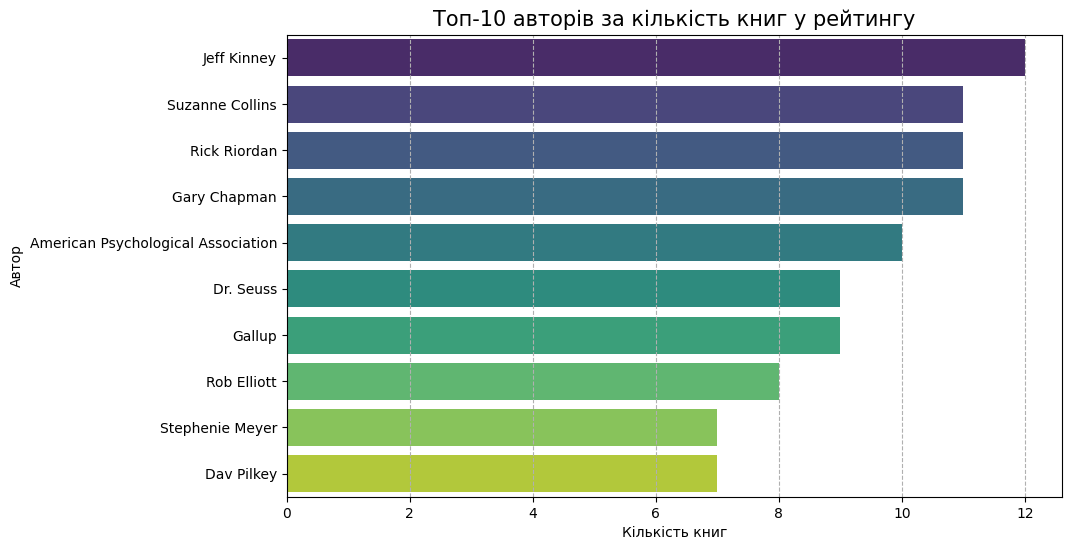

In [31]:
plt.figure(figsize=(10, 6))
top_authors = df["author"].value_counts().head(10)

sns.barplot(x=top_authors.values, y=top_authors.index, hue=top_authors.index, legend=False, palette='viridis')

plt.title("Топ-10 авторів за кількість книг у рейтингу", fontsize=15)
plt.xlabel("Кількість книг")
plt.ylabel("Автор")
plt.grid(axis='x', linestyle='--')
plt.show()

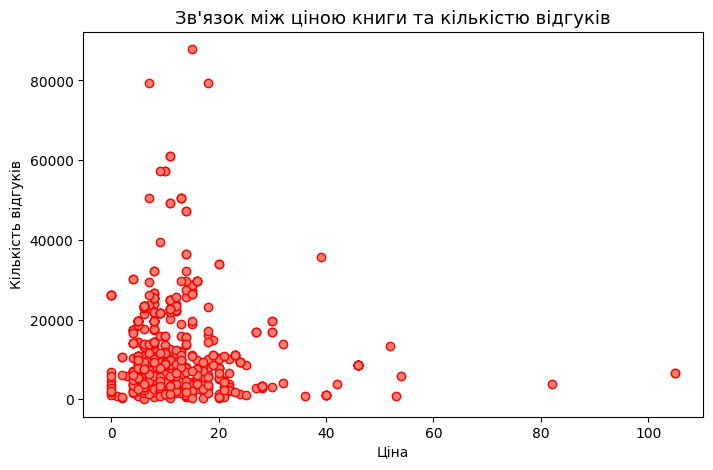

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(df['price'], df['reviews'], color='salmon', edgecolors='red')

plt.title('Зв\'язок між ціною книги та кількістю відгуків', fontsize=13)
plt.xlabel('Ціна')
plt.ylabel('Кількість відгуків')
plt.show()

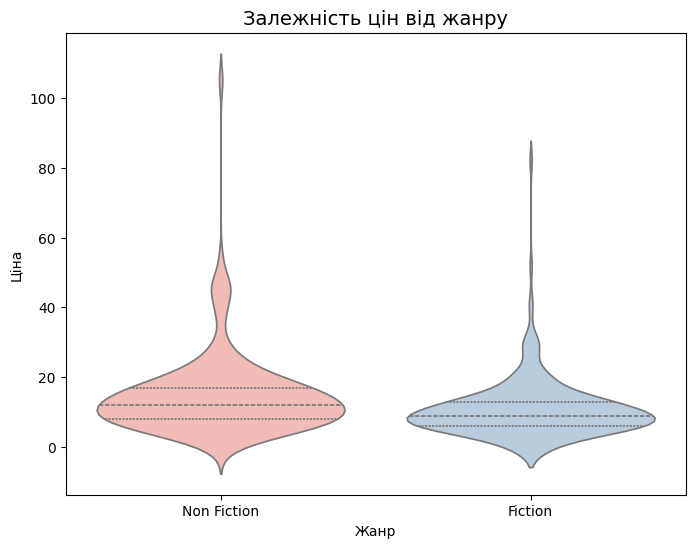

In [35]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='genre', y='price', data=df, inner='quart', hue='genre', legend=False, palette='Pastel1')

plt.title('Залежність цін від жанру', fontsize=14)
plt.xlabel('Жанр')
plt.ylabel('Ціна')
plt.show()